<a href="https://colab.research.google.com/github/shreetishresthanp/ml_theory/blob/main/homwork3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

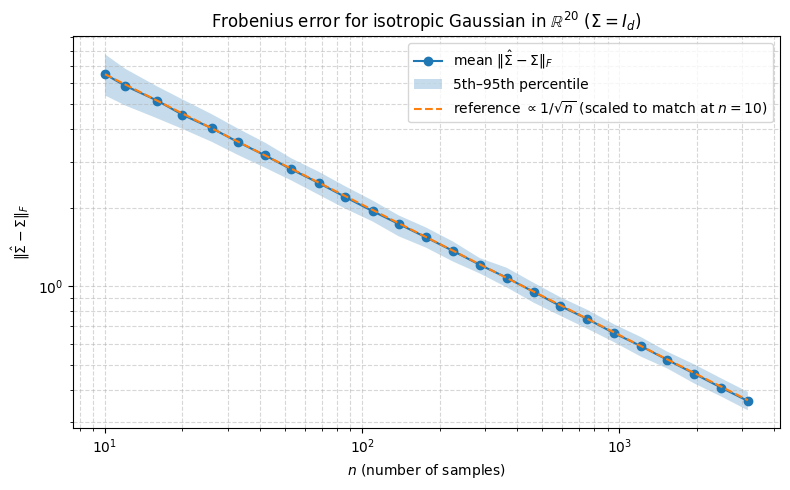

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

d = 20
n_list = np.unique(np.logspace(1, 3.5, 25).astype(int))  # n from ~10 to ~3000
n_trials = 200

Sigma = np.eye(d)
fro_errors = np.empty((len(n_list), n_trials))

for ni, n in enumerate(n_list):
    for t in range(n_trials):
        V = rng.standard_normal(size=(n, d))
        Sigma_hat = (V.T @ V) / n
        fro_errors[ni, t] = np.linalg.norm(Sigma_hat - Sigma, ord="fro")

mean_err = fro_errors.mean(axis=1)
q05 = np.quantile(fro_errors, 0.05, axis=1)
q95 = np.quantile(fro_errors, 0.95, axis=1)

# Reference curve ~ 1/sqrt(n) (same shape as typical matrix concentration rate in n)
n0 = float(n_list[0])
c = mean_err[0] * np.sqrt(n0)
ref = c / np.sqrt(n_list.astype(float))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(n_list, mean_err, "o-", label=r"mean $\|\hat{\Sigma}-\Sigma\|_F$")
ax.fill_between(n_list, q05, q95, alpha=0.25, label="5th–95th percentile")
ax.loglog(n_list, ref, "--", label=rf"reference $\propto 1/\sqrt{{n}}$ (scaled to match at $n={n0:.0f}$)")
ax.set_xlabel(r"$n$ (number of samples)")
ax.set_ylabel(r"$\|\hat{\Sigma} - \Sigma\|_F$")
ax.set_title(rf"Frobenius error for isotropic Gaussian in $\mathbb{{R}}^{{{d}}}$ ($\Sigma=I_d$)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()